In [9]:
file_path = "C:/Users/HP/Downloads/HEALTHCARE/HEALTHCARE/health_care_database/CALLOUT.csv"
df = pd.read_csv(file_path)
df.head()

,row_id,subject_id,hadm_id,submit_wardid,submit_careunit,curr_wardid,curr_careunit,callout_wardid,callout_service,request_tele,...,callout_status,callout_outcome,discharge_wardid,acknowledge_status,createtime,updatetime,acknowledgetime,outcometime,firstreservationtime,currentreservationtime
0,3917,10017,199207,7,NaN,45,CCU,1,MED,1,...,Inactive,Discharged,45.0,Acknowledged,2149-05-31 10:44:34,2149-05-31 10:44:34,2149-05-31 15:08:04,2149-05-31 22:40:02,NaN,NaN
1,3919,10026,103770,33,NaN,3,SICU,3,NMED,1,...,Inactive,Discharged,3.0,Revised,2195-05-18 13:56:20,2195-05-19 15:45:30,NaN,2195-05-19 17:40:03,NaN,NaN
2,3920,10027,199395,12,NaN,55,CSRU,55,CSURG,1,...,Inactive,Discharged,55.0,Acknowledged,2190-07-20 08:15:20,2190-07-20 08:15:20,2190-07-20 08:57:46,2190-07-20 17:10:02,NaN,NaN
3,3921,10029,132349,33,NaN,45,SICU,1,MED,0,...,Inactive,Discharged,45.0,Acknowledged,2139-09-24 09:53:37,2139-09-24 09:53:37,2139-09-24 09:56:02,2139-09-25 19:10:01,NaN,NaN
4,3922,10033,157235,33,NaN,4,SICU,1,MED,1,...,Inactive,Discharged,4.0,Revised,2132-12-06 10:16:08,2132-12-06 14:53:53,NaN,2132-12-06 15:10:02,NaN,NaN


In [10]:
# Conversion des colonnes temporelles en datetime
df['createtime'] = pd.to_datetime(df['createtime'], errors='coerce')
df['outcometime'] = pd.to_datetime(df['outcometime'], errors='coerce')

# Supprimer les lignes avec des dates manquantes
df = df.dropna(subset=['createtime', 'outcometime'])

# Supprimer les lignes avec des incohérences temporelles
df = df[df['outcometime'] >= df['createtime']]


In [11]:
# Calculer la durée en heures (tu peux changer en minutes si tu préfères)
df['callout_duration_hours'] = (df['outcometime'] - df['createtime']).dt.total_seconds() / 3600


In [12]:
# Extraire la date (sans l'heure) de la colonne createtime
df['callout_date'] = df['createtime'].dt.date

# Calcul de la moyenne des durées par jour
time_series = df.groupby('callout_date')['callout_duration_hours'].mean().reset_index()

# Renommer les colonnes pour plus de clarté
time_series.columns = ['date', 'avg_callout_duration_hours']


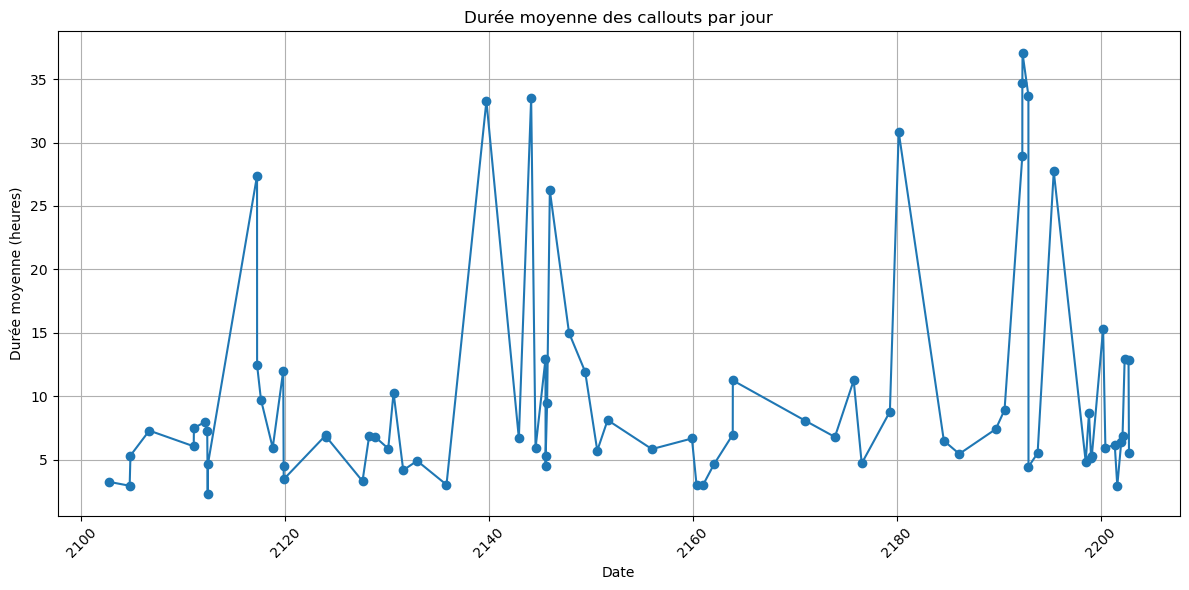

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(time_series['date'], time_series['avg_callout_duration_hours'], marker='o')
plt.title("Durée moyenne des callouts par jour")
plt.xlabel("Date")
plt.ylabel("Durée moyenne (heures)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# Transformer en index de série temporelle
time_series['date'] = pd.to_datetime(time_series['date'])
time_series.set_index('date', inplace=True)

# Remplir les dates manquantes (si certaines dates sont absentes)
time_series = time_series.asfreq('D')

# Interpolation linéaire pour les durées manquantes
time_series['avg_callout_duration_hours'] = time_series['avg_callout_duration_hours'].interpolate()


<Axes: title={'center': 'Durée moyenne des callouts (avec interpolation)'}, xlabel='date'>

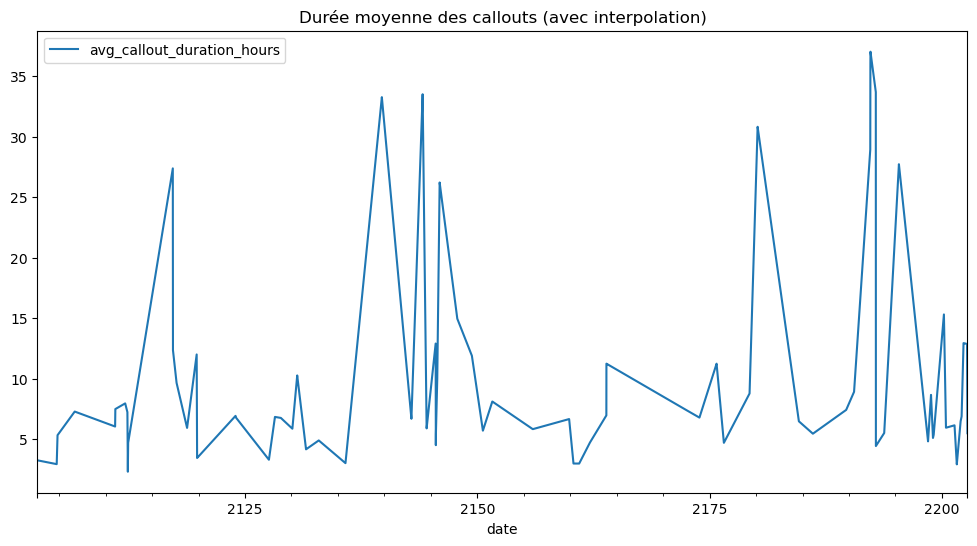

In [15]:
time_series.plot(figsize=(12, 6), title="Durée moyenne des callouts (avec interpolation)")


<Axes: title={'center': 'Série temporelle initiale'}, xlabel='date'>

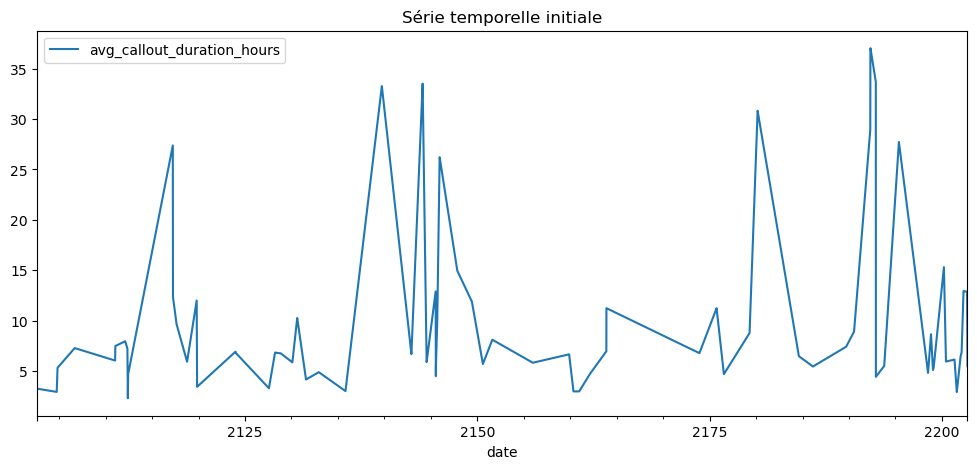

In [16]:
time_series.plot(title="Série temporelle initiale", figsize=(12, 5))


In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(time_series['avg_callout_duration_hours'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -3.8449415871107346
p-value: 0.0024795609228006853


In [18]:
pip install pmdarima


  Obtaining dependency information for pmdarima from https://files.pythonhosted.org/packages/ac/f8/6c9364602b13f0dba129b53acd1344859690911a4d5021560d9fd6aa087f/pmdarima-2.0.4-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for Cython!=0.29.18,!=0.29.31,>=0.29 from https://files.pythonhosted.org/packages/02/4e/5ac0b5b9a239cd3fdae187dda8ff06b0b812f671e2501bf253712278f0ac/Cython-3.0.12-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7 kB ? eta -:--:--
   - -------------------------------------- 30.7/614.7

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.


In [19]:
from pmdarima import auto_arima

# Supposons que ta série s'appelle time_series['avg_callout_duration_hours']
stepwise_model = auto_arima(
    time_series['avg_callout_duration_hours'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=0,              # d=0 car la série est déjà stationnaire
    seasonal=False,   # pas de saisonnalité ici
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(stepwise_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=286888.656, Time=0.36 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.79 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=3.34 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-68217.844, Time=2.68 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-72243.409, Time=4.75 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=1.15 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-72456.598, Time=9.50 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=1.37 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=-72920.053, Time=13.67 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=inf, Time=1.42 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=-73218.953, Time=17.96 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=inf, Time=5.20 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=-73219.234, Time=26.96 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=-71726.444, Time=21.86 sec
 ARIMA(5,0,3)(0,0,0)[0]             : AIC=-

In [20]:
from statsmodels.tsa.arima.model import ARIMA

# Création et entraînement du modèle ARIMA(2,0,4)
model = ARIMA(time_series['avg_callout_duration_hours'], order=(2, 0, 4))
model_fit = model.fit()

# Résumé (optionnel)
print(model_fit.summary())


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                   SARIMAX Results                                    
Dep. Variable:     avg_callout_duration_hours   No. Observations:                36558
Model:                         ARIMA(2, 0, 4)   Log Likelihood               36694.199
Date:                        Thu, 10 Apr 2025   AIC                         -73372.398
Time:                                20:39:46   BIC                         -73304.345
Sample:                            09-01-2102   HQIC                        -73350.766
                                 - 10-04-2202                                         
Covariance Type:                          opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.1376      2.645      3.833      0.000       4.953      15.322
ar.L1          1.9742      0.005    430.713      0.000       1.965 

<Axes: title={'center': 'Prévision de la durée moyenne des callouts (30 jours)'}>

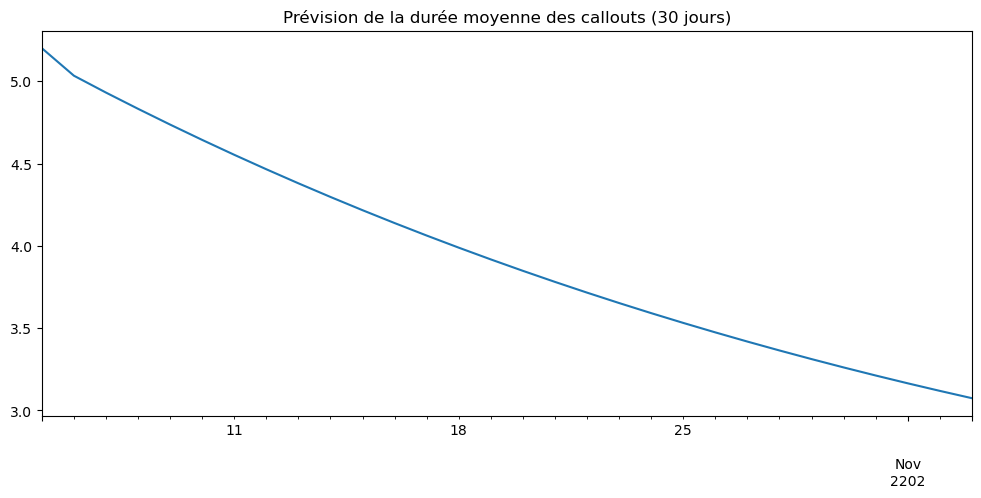

In [21]:
# Nombre de jours à prédire
n_steps = 30

# Prédiction future
forecast = model_fit.forecast(steps=n_steps)

# Affichage des résultats
forecast.index = pd.date_range(start=time_series.index[-1] + pd.Timedelta(days=1), periods=n_steps)
forecast.plot(figsize=(12, 5), title="Prévision de la durée moyenne des callouts (30 jours)")


In [23]:
Étapes pour évaluer les erreurs du modèle ARIMA
 

SyntaxError: invalid syntax (549657933.py, line 1)

In [24]:
# Nombre de jours pour le test
n_test = 30

# Découpage
train = time_series.iloc[:-n_test]
test = time_series.iloc[-n_test:]


In [25]:
#Entraîner le modèle sur les données train
from statsmodels.tsa.arima.model import ARIMA


model = ARIMA(train['avg_callout_duration_hours'], order=(2, 0, 4))
model_fit = model.fit()


In [26]:
#Prédire sur la période de test
forecast = model_fit.forecast(steps=n_test)

forecast.index = test.index  # pour aligner les dates


In [27]:
#Calculer les métriques d’erreur
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100  # en %

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAPE = {mape:.2f}%")
#Indicateur	Signification
#MAE = 2.06	En moyenne, l'erreur est d’environ 2 heures
#RMSE = 3.21	L’erreur moyenne avec pénalisation des grandes erreurs est de 3.2 heures

MAE  = 2.0641
RMSE = 3.2090
MAPE = nan%


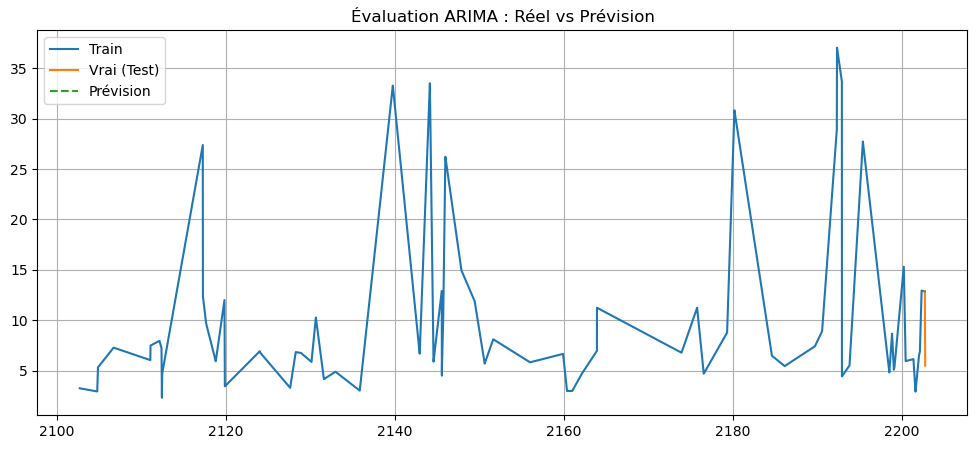

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Vrai (Test)")
plt.plot(forecast.index, forecast, label="Prévision", linestyle="--")
plt.legend()
plt.title("Évaluation ARIMA : Réel vs Prévision")
plt.grid(True)
plt.show()


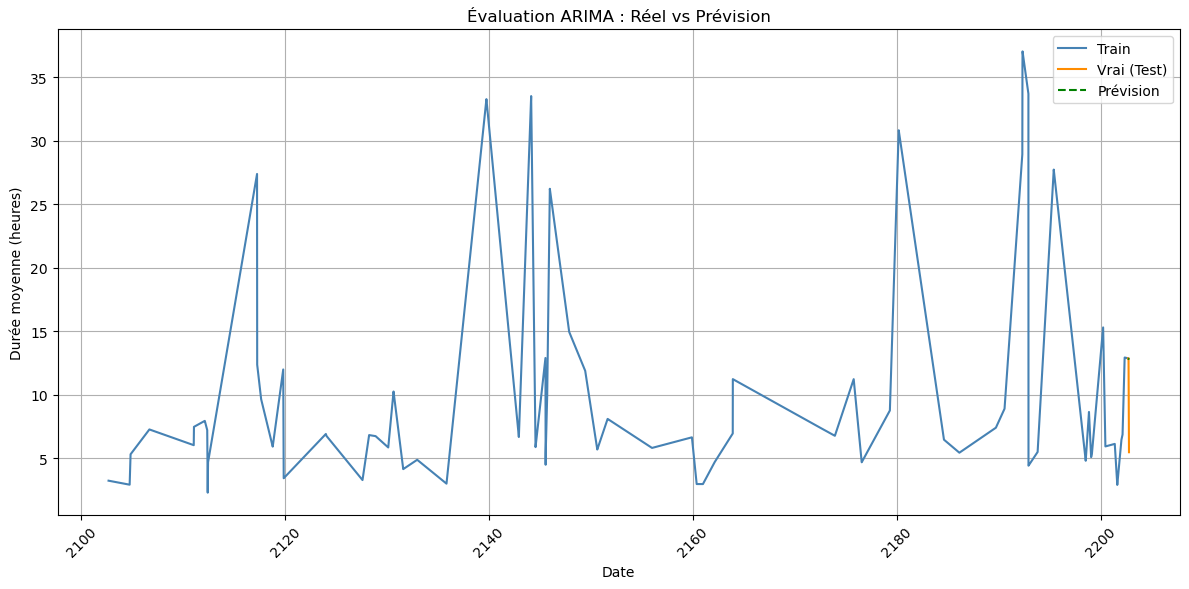

In [29]:
plt.figure(figsize=(12, 6))

# Série d'entraînement
plt.plot(train.index, train, label="Train", color='steelblue')

# Valeurs réelles (test)
plt.plot(test.index, test, label="Vrai (Test)", color='darkorange')

# Prévision
plt.plot(forecast.index, forecast, label="Prévision", color='green', linestyle='--')

plt.title("Évaluation ARIMA : Réel vs Prévision")
plt.xlabel("Date")
plt.ylabel("Durée moyenne (heures)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


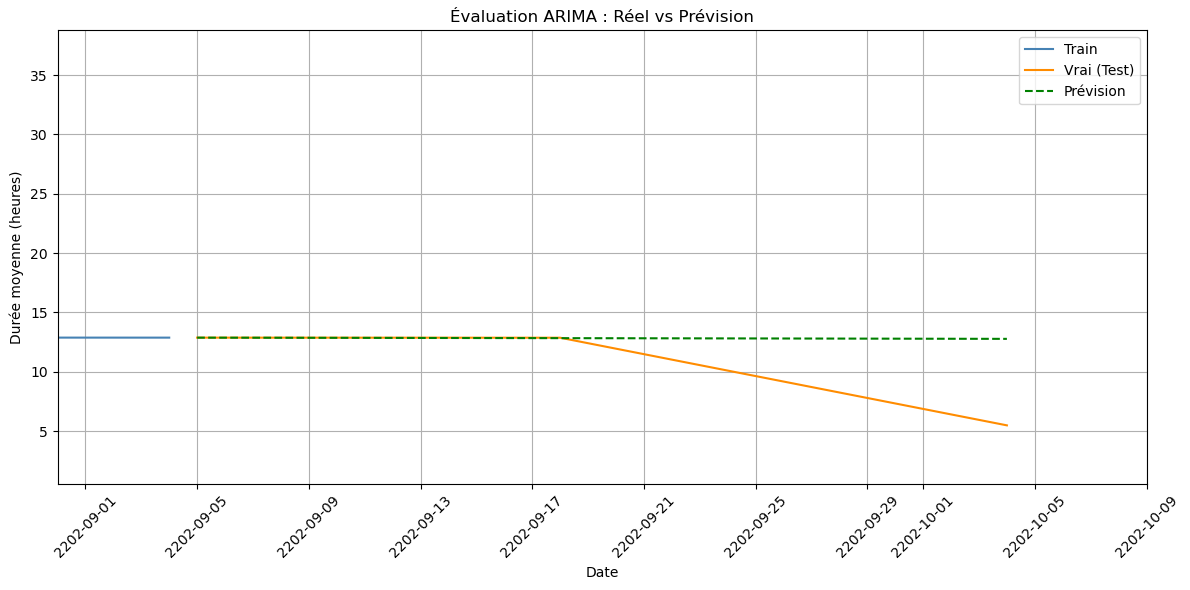

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(train.index, train, label="Train", color='steelblue')
plt.plot(test.index, test, label="Vrai (Test)", color='darkorange')
plt.plot(forecast.index, forecast, label="Prévision", color='green', linestyle='--')

plt.title("Évaluation ARIMA : Réel vs Prévision")
plt.xlabel("Date")
plt.ylabel("Durée moyenne (heures)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Zoom uniquement sur la zone test + prévision
plt.xlim(test.index.min() - pd.Timedelta(days=5), test.index.max() + pd.Timedelta(days=5))

plt.tight_layout()
plt.show()


In [33]:
n_test = 7  # seulement 1 semaine pour le test



In [34]:
print(train.tail(10))  # voir les dernières valeurs d'entraînement


            avg_callout_duration_hours
date                                  
2202-08-26                   12.881952
2202-08-27                   12.881445
2202-08-28                   12.880937
2202-08-29                   12.880430
2202-08-30                   12.879922
2202-08-31                   12.879414
2202-09-01                   12.878907
2202-09-02                   12.878399
2202-09-03                   12.877892
2202-09-04                   12.877384


In [40]:
!pip install prophet




  Obtaining dependency information for prophet from https://files.pythonhosted.org/packages/12/ff/a04156f4ca3d18bd005c73f79e86e0684346fbc2aea856429c3e49f2828e/prophet-1.1.6-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for cmdstanpy>=1.0.4 from https://files.pythonhosted.org/packages/2a/80/04b3989f055e555737b3b6944f02112e90cfc4f2e53c763771dded22e684/cmdstanpy-1.2.5-py3-none-any.whl.metadata
  Obtaining dependency information for holidays<1,>=0.25 from https://files.pythonhosted.org/packages/47/03/f92e1a10429c6d833b51841c9c9ba37721aac0097b0a9d2f83808fcf64e8/holidays-0.70-py3-none-any.whl.metadata
  Obtaining dependency information for importlib-resources from https://files.pythonhosted.org/packages/a4/ed/1f1afb2e9e7f38a545d628f864d562a5ae64fe6f7a10e28ffb9b185b4e89/importlib_resources-6.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for stanio<2.0.0,>=0.4.0 from https://files.pythonhosted.org/packages/56/87/37a80e4d5bd453c33262d8fb618b6840fd98d24ed0

In [41]:
from prophet import Prophet

# Créer une nouvelle DataFrame au format Prophet
df_prophet = time_series.reset_index()
df_prophet.columns = ['ds', 'y']  # Prophet exige ces noms-là



In [42]:
# Initialiser le modèle Prophet
model = Prophet()

# Entraîner le modèle
model.fit(df_prophet)



21:14:27 - cmdstanpy - INFO - Chain [1] start processing
21:14:59 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
future = model.make_future_dataframe(periods=30)


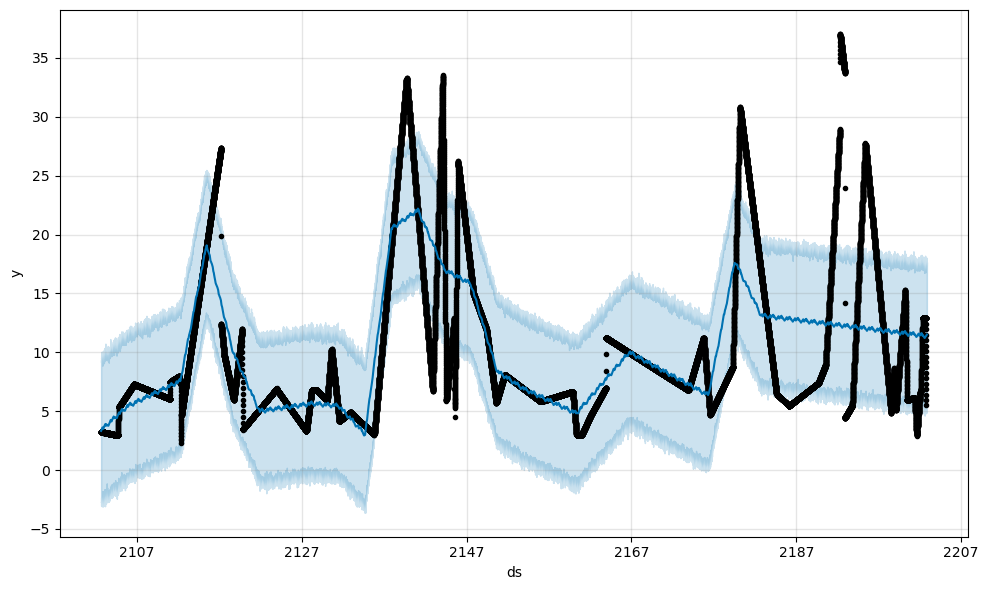

In [44]:
# Faire les prédictions
forecast = model.predict(future)

# Visualiser les résultats
model.plot(forecast);
#Les points noirs : ce sont tes valeurs réelles (historique)

#La ligne bleue : c’est la prédiction centrale (yhat)

#La zone bleue claire : c’est l’intervalle de confiance (généralement 80% ou 95%)

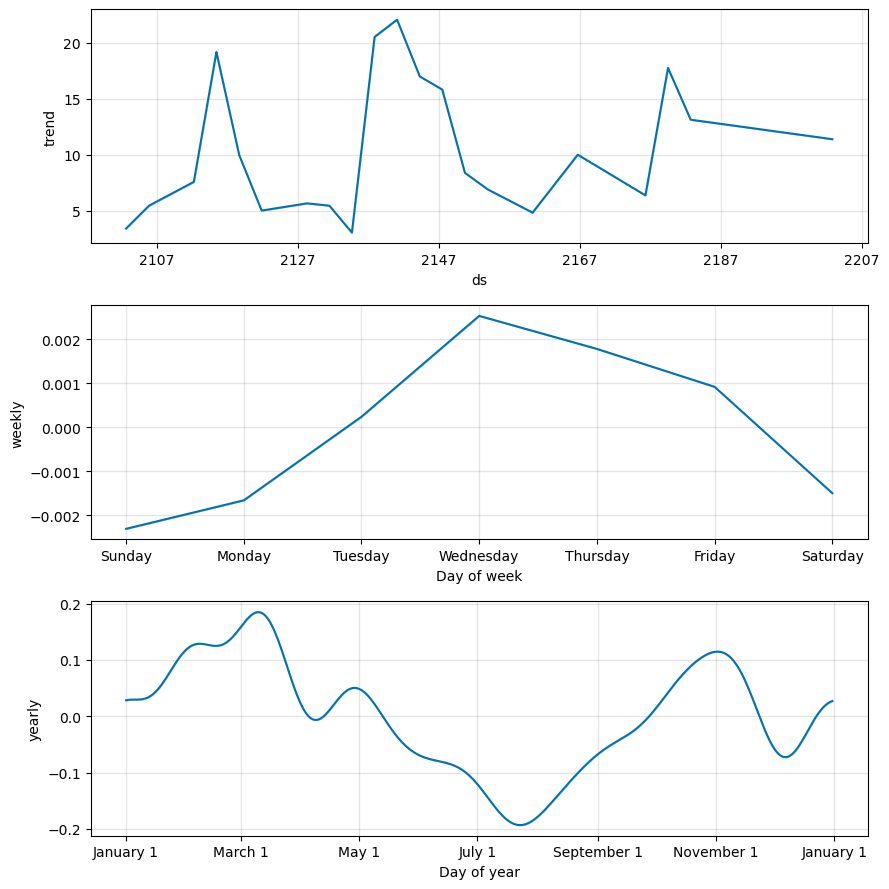

In [45]:
model.plot_components(forecast);


In [46]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)


,ds,yhat,yhat_lower,yhat_upper
36558,2202-10-05,11.412282,5.351967,17.449887
36559,2202-10-06,11.418816,5.587150,17.636460
36560,2202-10-07,11.422345,5.447595,17.431973
36561,2202-10-08,11.425782,5.530766,17.831748
36562,2202-10-09,11.427661,5.366087,17.787381
36563,2202-10-10,11.431128,5.534630,17.697541
36564,2202-10-11,11.436016,5.261894,18.039897
36565,2202-10-12,11.442099,5.260831,17.093773
36566,2202-10-13,11.448500,5.405688,17.634095
36567,2202-10-14,11.451759,4.962345,17.422777


In [47]:
# Fusion des prévisions avec les vraies valeurs
merged = forecast[['ds', 'yhat']].merge(df_prophet, on='ds', how='left')

# Supprimer les dates futures pour évaluer
evaluation = merged[~merged['y'].isna()]

# Erreurs
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(evaluation['y'], evaluation['yhat'])
rmse = np.sqrt(mean_squared_error(evaluation['y'], evaluation['yhat']))

print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")


MAE = 3.10
RMSE = 4.74
